# BioGPT LoRA Fine-tuning on PubMedQA

## Purpose
Fine-tune `microsoft/biogpt` on the PubMedQA training set using LoRA, producing an adapter to be compared against the zero-shot BioGPT baseline.

| Stage | Produces | Consumed by |
|-------|----------|-------------|
| This notebook (train) | `.models/biogpt_pubmedqa_lora`| Eval notebook |

## Workflow

1. Load base model in FP16 to save VRAM
2. Attach LoRA adapter 
3. Build training data
4. Train on 450 samples, validate on 50
5. Save adapter for the evaluation notebook

---
## SECTION 0 — CONFIG

In [ ]:
import os

# Base model
BASE_MODEL_ID = "microsoft/biogpt"
_SHARED_CACHE = r"E:\0000NLP_Models"
MODEL_CACHE_DIR = _SHARED_CACHE if os.path.isdir(_SHARED_CACHE) else None

# LoRA adapter output directory
LORA_OUTPUT_DIR = "./models/biogpt_pubmedqa_lora"

# Data
DATA_DIR = "data"

# Prompt template
PROMPT_TEMPLATE = "{question}\nContext: {context}\nAnswer (yes/no/maybe):"

# Input length
MAX_LENGTH = 1024

# LoRA hyperparameters
LORA_R           = 8 # Rank. Lower = fewer trainable params, more memory savings.
LORA_ALPHA       = 16 # Scaling factor; conventional 2*LORA_R.
LORA_DROPOUT     = 0.1
TARGET_MODULES   = ["q_proj", "v_proj"] # BioGPT attention projections.

# Training hyperparameters
NUM_EPOCHS       = 5
BATCH_SIZE       = 1
GRAD_ACCUM_STEPS = 8
LEARNING_RATE    = 1e-4
WARMUP_RATIO     = 0.1
LOGGING_STEPS    = 10
RANDOM_SEED      = 11

---
## SECTION 1 — Setup & Imports

In [7]:
import torch
import random
import numpy as np
from torch.utils.data import Dataset as TorchDataset
from transformers import (
    BioGptTokenizer,
    BioGptForCausalLM,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model, TaskType

from pubmed_loader import PubMedQAData
from preprocessing import build_input, get_label
from evaluation_plot import training_curves

# Reproducibility
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
PyTorch: 2.7.1+cu118
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.3 GB


---
## SECTION 2 — Load Base Model + Tokenizer

In [3]:
tokenizer = BioGptTokenizer.from_pretrained(BASE_MODEL_ID, cache_dir=MODEL_CACHE_DIR)

model = BioGptForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    cache_dir=MODEL_CACHE_DIR,
    torch_dtype=torch.float16,   # float16 halves the memory for weights
)

model.gradient_checkpointing_enable()
model.enable_input_require_grads()

# Extract token IDs for the three candidate labels
LABEL_TOKEN_IDS = {
    "yes":   tokenizer.encode("yes",   add_special_tokens=False)[0],
    "no":    tokenizer.encode("no",    add_special_tokens=False)[0],
    "maybe": tokenizer.encode("maybe", add_special_tokens=False)[0],
}
print("Label token IDs:", LABEL_TOKEN_IDS)

`torch_dtype` is deprecated! Use `dtype` instead!


Label token IDs: {'yes': 22700, 'no': 102, 'maybe': 22731}


---
## SECTION 3 — Attach LoRA Adapter

In [4]:
lora_config = LoraConfig(
    task_type = TaskType.CAUSAL_LM,
    r = LORA_R,
    lora_alpha = LORA_ALPHA,
    lora_dropout = LORA_DROPOUT,
    target_modules = TARGET_MODULES,
    bias = "none",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 786,432 || all params: 347,549,696 || trainable%: 0.2263


---
## SECTION 4 — Build Training Dataset


In [5]:
def format_sample(sample):
    '''
    Format one PubMedQA sample into (input_ids, attention_mask, labels).
    Loss is masked so only the final label token contributes.
    '''
    question, context = build_input(sample, use_mesh=False)
    label = get_label(sample)
    label_token_id = LABEL_TOKEN_IDS[label]

    prompt = PROMPT_TEMPLATE.format(question=question, context=context)

    prompt_ids = tokenizer(
        prompt,
        truncation = True,
        max_length = MAX_LENGTH - 1, # Leave 1 token for the label at the end
        add_special_tokens = True,
    )["input_ids"]

    input_ids = prompt_ids + [label_token_id]
    attention_mask = [1] * len(input_ids)
    # -100 on prompt tokens means they are not counted in loss. Only label token contributes.
    labels = [-100] * len(prompt_ids) + [label_token_id]
    '''
    The model is only trained in the last position (label position), 
    and the previous prompt part does not count as loss. 
    In other words, the model learns that "seeing this prompt, the next token should output 'yes/no/maybe'"
    '''
    return {
        "input_ids":      input_ids,
        "attention_mask": attention_mask,
        "labels":         labels,
    }


class PubMedQADataset(TorchDataset):
    def __init__(self, raw_dict):
        self.samples = [format_sample(s) for s in raw_dict.values()]
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx]


pubmedqa = PubMedQAData(DATA_DIR)
train_dataset = PubMedQADataset(pubmedqa.train_set)
dev_dataset   = PubMedQADataset(pubmedqa.dev_set)

print(f"Train samples: {len(train_dataset)}")
print(f"Dev   samples: {len(dev_dataset)}")

# Sanity check
sample = train_dataset[0]
print(f"\nSample 0 tokenized length: {len(sample['input_ids'])}")
print(f"Last token: {sample['input_ids'][-1]} "
      f"= '{tokenizer.decode([sample['input_ids'][-1]])}'") # yes/no/maybe
print(f"Labels end-slice: {sample['labels'][-3:]}")

Train samples: 450
Dev   samples: 50

Sample 0 tokenized length: 181
Last token (should be yes/no/maybe id): 22700 = 'yes'
Labels end-slice: [-100, -100, 22700]  (only last should be != -100)


---
## SECTION 5 — Data Collator (dynamic padding)

Aligning samples of different lengths in a batch into tensors of the same length

In [ ]:
#PAD_ID = tokenizer.pad_token_id 
#if tokenizer.pad_token_id is not None else tokenizer.eos_token_id

def collate_fn(batch):
    # Pad to the longest sequence in the batch. Label pad = -100 (ignored in loss)
    max_len = max(len(x["input_ids"]) for x in batch)
    input_ids, attention_mask, labels = [], [], []
    for x in batch:
        pad_len = max_len - len(x["input_ids"])
        input_ids.append(x["input_ids"] + [tokenizer.pad_token_id] * pad_len)
        attention_mask.append(x["attention_mask"] + [0] * pad_len)
        labels.append(x["labels"] + [-100] * pad_len)
    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.long),
    }

---
## SECTION 6 — Train

Expected runtime on 4 GB GPU

In [8]:
training_args = TrainingArguments(
    output_dir                  = LORA_OUTPUT_DIR,
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM_STEPS,
    gradient_checkpointing      = True,
    learning_rate               = LEARNING_RATE,
    warmup_ratio                = WARMUP_RATIO,
    fp16                        = True,
    # logging_steps               = LOGGING_STEPS,
    logging_strategy            = "epoch",
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,
    report_to                   = "none",
    remove_unused_columns       = False,
    seed                        = RANDOM_SEED,
)

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = train_dataset,
    eval_dataset  = dev_dataset,
    data_collator = collate_fn,
)

trainer.train()

`use_cache=True` is incompatible with gradient checkpointing`. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
1,5.909000,1.225588
2,1.196300,0.977290
3,1.071600,1.042520
4,1.071600,0.979228
5,1.069000,0.954177


TrainOutput(global_step=285, training_loss=2.0635010836417216, metrics={'train_runtime': 260.5981, 'train_samples_per_second': 8.634, 'train_steps_per_second': 1.094, 'total_flos': 1198576223723520.0, 'train_loss': 2.0635010836417216, 'epoch': 5.0})

Collected 5 train loss points
Collected 5 eval loss points


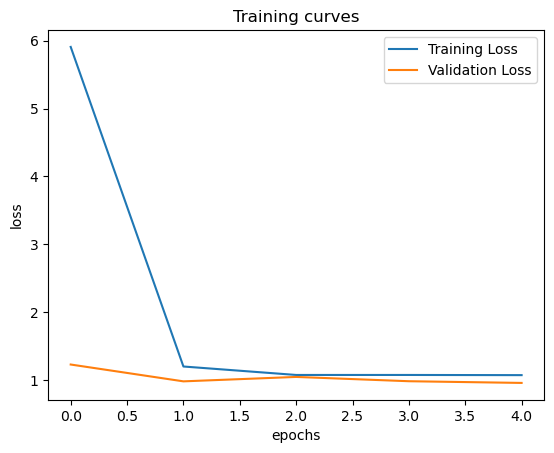

In [9]:
train_losses = []
dev_losses   = []

for log in trainer.state.log_history:
    if "loss" in log and "eval_loss" not in log:
        train_losses.append(log["loss"])
    if "eval_loss" in log:
        dev_losses.append(log["eval_loss"])

print(f"Collected {len(train_losses)} train loss points")
print(f"Collected {len(dev_losses)} eval loss points")

training_curves(train_losses, dev_losses)

---
## SECTION 7 — Save Adapter

In [10]:
# Saves the LoRA adapter
model.save_pretrained(LORA_OUTPUT_DIR)
tokenizer.save_pretrained(LORA_OUTPUT_DIR)

print(f"LoRA adapter saved to: {os.path.abspath(LORA_OUTPUT_DIR)}")
print("Contents:")
for f in sorted(os.listdir(LORA_OUTPUT_DIR)):
    path = os.path.join(LORA_OUTPUT_DIR, f)
    if os.path.isfile(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"  {f}  ({size_kb:.1f} KB)")

LoRA adapter saved to: e:\files\Bristol\AITA\courseWork\AITA_Coursework_Team11\models\biogpt_pubmedqa_lora
Contents:
  README.md  (5.1 KB)
  adapter_config.json  (1.0 KB)
  adapter_model.safetensors  (3084.4 KB)
  merges.txt  (483.9 KB)
  special_tokens_map.json  (0.1 KB)
  tokenizer_config.json  (1.0 KB)
  vocab.json  (946.7 KB)
